<div style="
    padding:18px 20px;
    border-radius:10px;
    background:#16324F;
    margin-bottom:18px;
">

<h1 style="
    margin:0;
    color:white;
">
Day 5 - Scikit-learn Pipelines & Tuned Mini-Project
</h1>

<p style="
    margin-top:8px;
    margin-bottom:0;
    color:#EAF3F5;
">
Building a complete leak-free machine learning workflow.
</p>

</div>

<div style="
    padding:14px 16px;
    border-radius:9px;
    background:#ffffff;
    border:1px solid #DCE5E8;
    margin:12px 0;
">

<h2 style="
    margin-top:0;
    color:#2F6F7E;
">
Introduction
</h2>

<p style="color:#3F4A52;">
In the previous days, preprocessing, feature engineering, model evaluation, and tuning were handled in separate steps.
</p>

<p style="color:#3F4A52;">
Today, I will combine these steps into one Scikit-learn Pipeline so that preprocessing and model training are applied in the correct order without data leakage.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
I will continue using the Pima Indians Diabetes Dataset and the engineered features created in Day 4.
</p>

</div>

<h2 style="color:#2F6F7E;">
Objectives
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0;
">
<ul style="color:#3F4A52; margin-bottom:0;">
<li>Build a leak-free Pipeline that combines preprocessing and modeling.</li>
<li>Use ColumnTransformer for numerical and categorical features.</li>
<li>Tune the full Pipeline using GridSearchCV and 5-fold cross-validation.</li>
<li>Evaluate the final tuned model on a held-out test set.</li>
</ul>
</div>

<h2 style="color:#2F6F7E;">
Topics Covered
</h2>

<div style="
    background:#F6F9FA;
    border-radius:9px;
    padding:12px 14px;
    color:#3F4A52;
">
Pipeline • Data Leakage • ColumnTransformer • StandardScaler • OneHotEncoder • FunctionTransformer • Random Forest • GridSearchCV • StratifiedKFold • F1-score • Confusion Matrix
</div>

<h2 style="color:#2F6F7E;">
Reading Guide
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 16px 0;
">

<ul style="
    color:#3F4A52;
    margin:0;
    padding-left:20px;
    line-height:1.8;
">

<li>
Start with why data leakage can happen when preprocessing is handled manually.
</li>

<li>
See how Pipeline and ColumnTransformer organize preprocessing and modeling into one workflow.
</li>

<li>
Follow the Day 4 engineered features as they become part of the final Pipeline.
</li>

<li>
Explore how GridSearchCV tests multiple Random Forest configurations using 5-fold cross-validation.
</li>

<li>
Compare the tuned Pipeline with an untuned baseline on the held-out test set.
</li>

<li>
Use the confusion matrix and performance plots to understand the model beyond a single F1-score.
</li>

<li>
Finish with the main lessons learned from building a complete leak-free machine learning workflow.
</li>

</ul>

</div>

<h2 style="color:#2F6F7E;">
Import Libraries
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
The required tools are imported before building the workflow. These tools will be used for preprocessing, pipeline construction, hyperparameter tuning, cross-validation, and final evaluation.
</p>

In [246]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    ConfusionMatrixDisplay
)
from sklearn import set_config

<h2 style="color:#2F6F7E;">
5.1 - Why Pipelines Exist
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52; margin-top:0;">
In previous notebooks, preprocessing and model training were performed as separate steps.
</p>

<p style="color:#3F4A52;">
This can become risky during cross-validation because preprocessing may accidentally learn information from data that should remain unseen.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
A Pipeline keeps preprocessing and modeling together, so each step is fitted in the correct order using only the training portion of the data.
</p>

</div>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Key Question:</b><br>
What could happen if preprocessing is fitted before cross-validation?
</p>

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Answer:</b><br>
Information from validation folds may influence the preprocessing step. This creates data leakage and can make the evaluation look better than the model's real performance.
</p>

<h2 style="color:#2F6F7E;">
5.2 - Building a Pipeline
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
">

<p style="color:#3F4A52; margin-top:0;">
A Scikit-learn Pipeline connects several machine learning steps into one object.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
When <code>fit()</code> is called, the data passes through preprocessing first and then into the model. The same fitted preprocessing is automatically used later during prediction.
</p>

</div>

In [247]:
# Simple example of a Pipeline
simple_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

simple_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The Pipeline contains two ordered steps: preprocessing with StandardScaler followed by the Random Forest model. Both steps can now be managed as one machine learning workflow.
</p>

<h2 style="color:#2F6F7E;">
5.3 - ColumnTransformer for Mixed Data
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
">

<p style="color:#3F4A52; margin-top:0;">
Real datasets may contain different feature types, and they should not always receive the same preprocessing.
</p>

<p style="color:#3F4A52;">
Numerical features can be scaled with <code>StandardScaler</code>, while categorical features can be converted into numerical values using <code>OneHotEncoder</code>.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
ColumnTransformer lets both operations happen inside the same preprocessing step.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-radius:9px;
    padding:12px 14px;
    margin:12px 0;
    color:#3F4A52;
">
<b style="color:#2F6F7E;">ColumnTransformer Flow</b><br><br>
Numeric Features → StandardScaler<br>
Categorical Features → OneHotEncoder<br>
↓<br>
Combined Processed Features
</div>

<h2 style="color:#2F6F7E;">
5.4 - Tuning a Whole Pipeline
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
">

<p style="color:#3F4A52; margin-top:0;">
GridSearchCV can tune a model even when the model is inside a Pipeline.
</p>

<p style="color:#3F4A52;">
Pipeline parameters use a double underscore between the step name and the parameter name.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
For example, <code>model__max_depth</code> means the <code>max_depth</code> parameter of the step named <code>model</code>.
</p>

</div>

<h2 style="color:#2F6F7E;">
5.5 - The Week 4 Mini-Project
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
">

<p style="color:#3F4A52; margin-top:0;">
The final task of Week 4 brings the main ideas of the week into one workflow.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
The workflow will combine engineered features, preprocessing, Random Forest classification, GridSearchCV, cross-validation, and one final evaluation on untouched test data.
</p>

</div>

<h1 style="
    color:#16324F;
    font-weight:bold;
">
Hands-On Lab — Tuned End-to-End Pipeline
</h1>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52; margin-top:0;">
In this lab, I will build a complete leak-free machine learning workflow using a Pipeline and ColumnTransformer.
</p>

<p style="color:#3F4A52; margin-bottom:0;">
I will reuse the engineered features from Day 4, tune the full pipeline with GridSearchCV, and evaluate the final model once on the held-out test set.
</p>

</div>

<h2 style="color:#2F6F7E;">
Load the Raw Dataset
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
I will start with the raw diabetes dataset. The engineered features from Day 4 will be created later inside the Pipeline.
</p>

In [248]:
# Load the same raw diabetes dataset used in Day 4
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
The Pima Indians Diabetes Dataset is loaded into a Pandas DataFrame. Each row represents one patient, while the Outcome column shows whether the patient has diabetes.
</p>

In [249]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

df.info()

Dataset shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   76

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The raw dataset contains <b>768 records</b> and <b>9 columns</b>, including the target column <code>Outcome</code>. The dataset was checked before starting the pipeline workflow.
</p>

<h2 style="color:#2F6F7E;">
Prepare Features and Target
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
I will separate the input features from the target before creating the preprocessing pipeline.
</p>

In [250]:
# Separate input features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The input data contains <b>8 original features</b>, while <code>Outcome</code> is used as the target variable. The engineered features will be created later inside the Pipeline.
</p>

<h2 style="color:#2F6F7E;">
Split the Data
</h2>

In [251]:
# Keep the test set untouched for the final evaluation
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (614, 8)
Testing shape: (154, 8)


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The dataset was split into training and testing sets. The test set will remain untouched until the final pipeline evaluation.
</p>

<h2 style="color:#2F6F7E;">
Prepare the Feature Engineering Step
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
The two features created in Day 4 will be defined as a reusable transformation. FunctionTransformer allows this feature engineering step to become part of the final Pipeline instead of being applied manually before training.
</p>

In [252]:
# Recreate the engineered features from Day 4
def add_engineered_features(data):
    data = data.copy()

    data["BMI_Category"] = pd.cut(
        data["BMI"],
        bins=[-0.1, 18.5, 25, 30, 100],
        labels=[
            "Underweight",
            "Normal",
            "Overweight",
            "Obese"
        ]
    )

    data["Glucose_Age_Risk"] = (
        data["Glucose"] * data["Age"]
    )

    return data

In [253]:
feature_engineering = FunctionTransformer(
    add_engineered_features,
    validate=False
)

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The Day 4 feature engineering logic is now wrapped inside a FunctionTransformer. This allows the same transformations to be applied automatically during training, cross-validation, and prediction.
</p>

<h2 style="color:#2F6F7E;">
Step 1 - Build a Pipeline with a ColumnTransformer
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Task:</b><br>
Build a Pipeline with a ColumnTransformer handling numeric (scaling) and categorical (encoding) columns.
</p>

In [254]:
# Identify numerical and categorical features
numeric_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Glucose_Age_Risk"
]

categorical_cols = [
    "BMI_Category"
]

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_Age_Risk']

Categorical columns:
['BMI_Category']


<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
Numerical features will be scaled using StandardScaler, while categorical features will be encoded using OneHotEncoder.
</p>

In [255]:
# Create preprocessing for numerical and categorical features
preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        [
            "Pregnancies",
            "Glucose",
            "BloodPressure",
            "SkinThickness",
            "Insulin",
            "BMI",
            "DiabetesPedigreeFunction",
            "Age",
            "Glucose_Age_Risk"
        ]
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        [
            "BMI_Category"
        ]
    )
])

In [256]:
pipeline = Pipeline([
    (
        "feature_engineering",
        feature_engineering
    ),
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001E679926FC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defa

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The Pipeline now combines feature engineering, preprocessing, and modeling in one workflow. The Day 4 features are created first, numerical features are scaled, categorical features are encoded, and the processed data is then passed to the Random Forest model.
</p>

<h2 style="color:#2F6F7E;">
Step 2 - Add the Engineered Features from Day 4
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Task:</b><br>
Add the engineered features from Day 4 into the workflow and verify that each one is handled by the correct preprocessing step.
</p>

In [257]:
# Apply the feature engineering step to a small preview
engineered_preview = add_engineered_features(
    x_train.head()
)

engineered_preview[
    ["BMI_Category", "Glucose_Age_Risk"]
]

,BMI_Category,Glucose_Age_Risk
353,Overweight,2160
711,Overweight,5040
373,Obese,2625
46,Overweight,4234
682,Obese,2090


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The Day 4 engineered features were created successfully. 
<code>BMI_Category</code> was added as a categorical feature, while 
<code>Glucose_Age_Risk</code> was added as a numerical feature.
</p>

In [ ]:
# Verify the preprocessing path for each engineered feature
print(
    "BMI_Category routed to categorical preprocessing:",
    "BMI_Category" in categorical_cols
)

print(
    "Glucose_Age_Risk routed to numerical preprocessing:",
    "Glucose_Age_Risk" in numeric_cols
)

BMI_Category routed to categorical preprocessing: True
Glucose_Age_Risk routed to numerical preprocessing: True


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
Both checks returned <b>True</b>. <code>BMI_Category</code> is routed to categorical preprocessing, while <code>Glucose_Age_Risk</code> is routed to numerical preprocessing.
</p>

In [259]:

# Display the complete pipeline structure
set_config(display="diagram")

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001E679926FC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defa

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Pipeline Structure:</b><br>
The diagram shows the complete workflow from feature engineering to preprocessing and Random Forest classification. Keeping these steps inside one Pipeline ensures that the same sequence is applied consistently during training, cross-validation, and prediction.
</p>

<h2 style="color:#2F6F7E;">
Step 3 - Tune the Full Pipeline with GridSearchCV
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Task:</b><br>
Tune the full pipeline with GridSearchCV and 5-fold cross-validation.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
Instead of tuning the Random Forest separately, I will tune the model inside the Pipeline. This keeps preprocessing and model training together during cross-validation.
</p>

In [260]:
# Define hyperparameters for the model inside the pipeline
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

param_grid

{'model__n_estimators': [100, 200],
 'model__max_depth': [5, 10, None],
 'model__min_samples_split': [2, 5]}

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The grid contains three Random Forest hyperparameters. The double underscore in names such as <code>model__n_estimators</code> tells GridSearchCV that the parameter belongs to the <code>model</code> step inside the Pipeline.
</p>

In [261]:
# Calculate the number of combinations and total model fits
n_combinations = (
    len(param_grid["model__n_estimators"]) *
    len(param_grid["model__max_depth"]) *
    len(param_grid["model__min_samples_split"])
)

n_fits = n_combinations * 5

print("Hyperparameter combinations:", n_combinations)
print("Total model fits with 5-fold CV:", n_fits)

Hyperparameter combinations: 12
Total model fits with 5-fold CV: 60


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
GridSearchCV will test <b>12 hyperparameter combinations</b>. With 5-fold cross-validation, the complete Pipeline will be fitted <b>60 times</b>.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
StratifiedKFold will keep a similar proportion of diabetes and non-diabetes cases in each cross-validation fold.
</p>

In [262]:
# Create stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_strategy

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Tune the complete preprocessing + model pipeline




In [263]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

# Run the search on the training data only

In [264]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The full Pipeline was tuned using only the training data. During each fold, the preprocessing steps were fitted on that fold's training portion before the Random Forest model was trained.
</p>

In [265]:
# Show the best pipeline settings and cross-validation score
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV F1-score:
0.6451085240550418


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
GridSearchCV selected <code>max_depth=10</code>, <code>min_samples_split=2</code>, and <code>n_estimators=100</code> as the best settings for the Random Forest inside the Pipeline.<br><br>

The best cross-validation F1-score was approximately <b>0.645</b>.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">What does this mean?</b><br>
The best Pipeline configuration used a limited tree depth of 10. This suggests that some control over tree complexity gave better average cross-validation performance than the other tested settings.
</p>

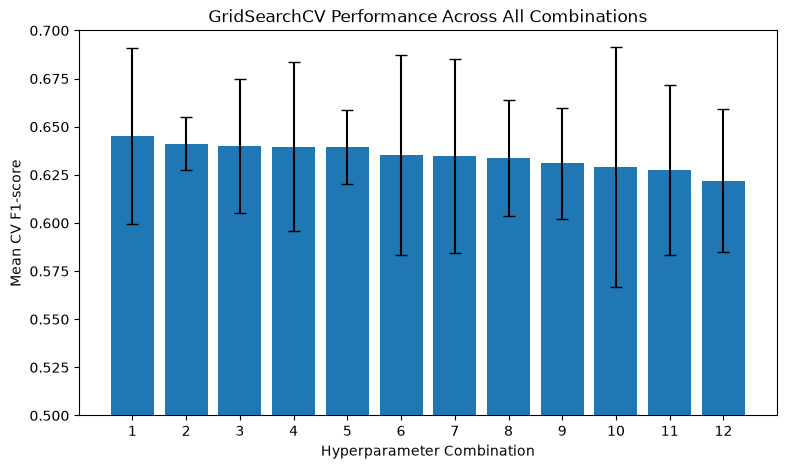

In [266]:
# Collect all GridSearchCV results
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results = grid_results.sort_values(
    "mean_test_score",
    ascending=False
).reset_index(drop=True)

grid_results["Combination"] = range(
    1,
    len(grid_results) + 1
)

plt.figure(figsize=(9, 5))

plt.bar(
    grid_results["Combination"],
    grid_results["mean_test_score"],
    yerr=grid_results["std_test_score"],
    capsize=4
)

plt.xlabel("Hyperparameter Combination")
plt.ylabel("Mean CV F1-score")
plt.title(
    "GridSearchCV Performance Across All Combinations"
)

plt.xticks(grid_results["Combination"])
plt.ylim(0.5, 0.7)

plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Plot Analysis:</b><br>
The chart compares the mean cross-validation F1-score of all 12 hyperparameter combinations. The error bars show the variation across the five folds.<br><br>

The results are relatively close, indicating that no tested configuration produced a dramatic improvement over the others. GridSearchCV selected the combination with the highest average F1-score.
</p>

<h2 style="color:#2F6F7E;">
Step 4 - Final Test Evaluation and Baseline Comparison
</h2>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Task:</b><br>
Evaluate the final tuned pipeline once on the held-out test set and report the metric against a baseline.
</p>

In [267]:
# Get the best tuned pipeline
best_pipeline = grid_search.best_estimator_

# Predict the untouched test set
test_predictions = best_pipeline.predict(x_test)

# Calculate the final test F1-score
test_f1 = f1_score(
    y_test,
    test_predictions
)

print(
    "Tuned Pipeline Test F1-score:",
    test_f1
)

Tuned Pipeline Test F1-score: 0.6415094339622641


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The tuned Pipeline achieved a final test F1-score of approximately <b>0.642</b>.<br><br>

This result is close to the best cross-validation F1-score of <b>0.645</b>, which suggests that the tuned Pipeline performed similarly on unseen test data.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
I will inspect the confusion matrix of the tuned Pipeline to understand how its predictions are distributed across the two classes.
</p>

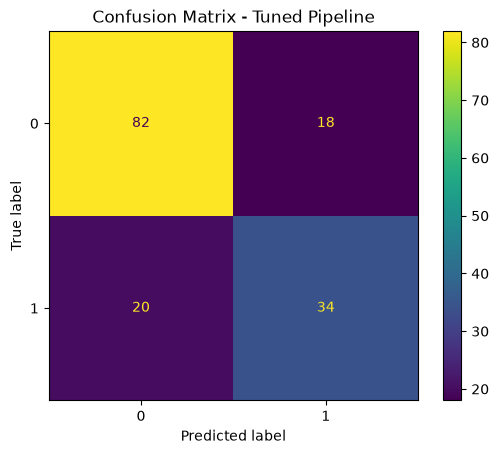

In [268]:
# Display the confusion matrix for the tuned pipeline
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions
)

plt.title("Confusion Matrix - Tuned Pipeline")
plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The tuned Pipeline correctly classified <b>82 non-diabetes cases</b> and <b>34 diabetes cases</b>.<br><br>

It incorrectly predicted <b>18 non-diabetes cases</b> as diabetes, while <b>20 actual diabetes cases</b> were missed.<br><br>

This shows that the model performs better at identifying non-diabetes cases than diabetes cases. The missed positive cases help explain why the F1-score remains around <b>0.642</b>.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">What does this mean?</b><br>
The model detected 34 out of 54 actual diabetes cases, but missed 20 of them. This means the positive class is more difficult for the model to identify consistently.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
To make a fair comparison, I will evaluate an untuned baseline Pipeline using the same preprocessing steps and the same held-out test set.
</p>

In [269]:
baseline_pipeline = Pipeline([
    (
        "feature_engineering",
        FunctionTransformer(
            add_engineered_features,
            validate=False
        )
    ),
    (
        "preprocessor",
        ColumnTransformer([
            (
                "num",
                StandardScaler(),
                [
                    "Pregnancies",
                    "Glucose",
                    "BloodPressure",
                    "SkinThickness",
                    "Insulin",
                    "BMI",
                    "DiabetesPedigreeFunction",
                    "Age",
                    "Glucose_Age_Risk"
                ]
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                [
                    "BMI_Category"
                ]
            )
        ])
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

baseline_pipeline.fit(x_train, y_train)

baseline_predictions = baseline_pipeline.predict(
    x_test
)

baseline_test_f1 = f1_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline Pipeline Test F1-score:",
    baseline_test_f1
)

print(
    "Tuned Pipeline Test F1-score:",
    test_f1
)

Baseline Pipeline Test F1-score: 0.6538461538461539
Tuned Pipeline Test F1-score: 0.6415094339622641


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The baseline Pipeline achieved a test F1-score of approximately <b>0.654</b>, while the tuned Pipeline achieved approximately <b>0.642</b>.<br><br>

The tuned Pipeline did not improve the baseline on the held-out test set. The difference is small, which suggests that the default Random Forest settings were already competitive for this dataset.
</p>

In [270]:
# Get the 5 fold scores of the best GridSearchCV combination
best_index = grid_search.best_index_

best_pipeline_cv_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][best_index]
    for i in range(5)
]

best_pipeline_cv_scores = pd.Series(
    best_pipeline_cv_scores
)

print("Best Pipeline CV F1-scores:")
print(best_pipeline_cv_scores.values)

print("\nMean F1-score:", best_pipeline_cv_scores.mean())
print("Standard deviation:", best_pipeline_cv_scores.std(ddof=0))

Best Pipeline CV F1-scores:
[0.66666667 0.575      0.67532468 0.6097561  0.69879518]

Mean F1-score: 0.6451085240550418
Standard deviation: 0.04566185633278359


In [271]:
# Compare baseline and tuned test performance
comparison = pd.DataFrame({
    "Model": ["Baseline Pipeline", "Tuned Pipeline"],
    "Test F1-score": [baseline_test_f1, test_f1]
})

comparison

,Model,Test F1-score
0,Baseline Pipeline,0.653846
1,Tuned Pipeline,0.641509


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The comparison confirms that the baseline Pipeline performed slightly better on the test set. This shows that hyperparameter tuning does not always guarantee better performance on unseen data.
</p>

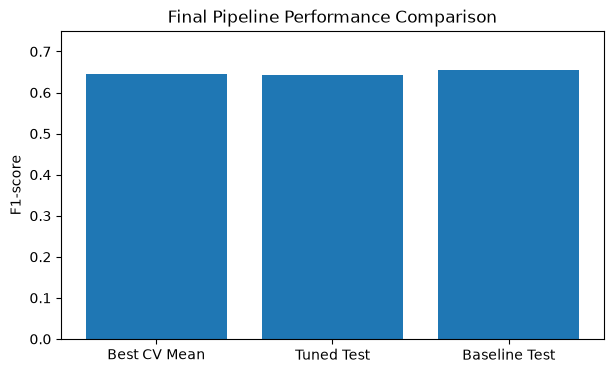

In [272]:
# Compare the main final scores
final_scores = pd.DataFrame({
    "Evaluation": [
        "Best CV Mean",
        "Tuned Test",
        "Baseline Test"
    ],
    "F1-score": [
        best_pipeline_cv_scores.mean(),
        test_f1,
        baseline_test_f1
    ]
})

plt.figure(figsize=(7, 4))

plt.bar(
    final_scores["Evaluation"],
    final_scores["F1-score"]
)

plt.ylabel("F1-score")
plt.title("Final Pipeline Performance Comparison")
plt.ylim(0, 0.75)

plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Plot Analysis:</b><br>
The tuned Pipeline achieved a cross-validation mean F1-score of about <b>0.645</b> and a test F1-score of about <b>0.642</b>. The baseline Pipeline achieved a slightly higher test F1-score of about <b>0.654</b>.<br><br>

The three scores are relatively close, showing that the Pipeline produced similar performance across cross-validation and held-out test evaluation, while tuning did not outperform the baseline.
</p>

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Note:</b><br>
I will inspect the F1-score from each cross-validation fold to see how consistent the best Pipeline was across different training and validation splits.
</p>

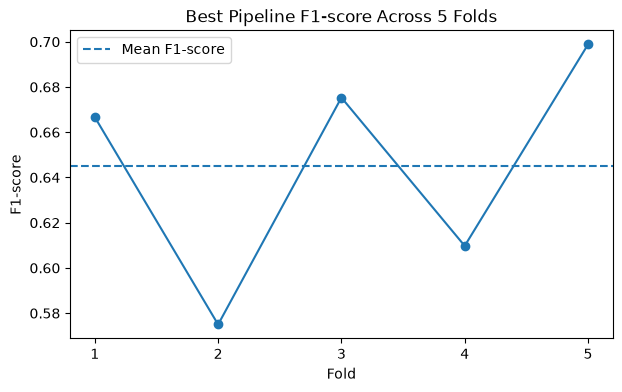

In [273]:
# Visualize F1-score across the five folds
fold_numbers = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 4))

plt.plot(
    fold_numbers,
    best_pipeline_cv_scores,
    marker="o"
)

plt.axhline(
    best_pipeline_cv_scores.mean(),
    linestyle="--",
    label="Mean F1-score"
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Best Pipeline F1-score Across 5 Folds")
plt.xticks(fold_numbers)
plt.legend()

plt.show()

<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">Plot Analysis:</b><br>
The fold scores fluctuate around the mean F1-score of approximately <b>0.645</b>. Fold 2 produced the lowest score of about <b>0.575</b>, while Fold 5 produced the highest score of about <b>0.699</b>.<br><br>

The remaining folds stayed relatively close to the average, showing moderate variation in performance across the five validation splits.
</p>

<h2 style="color:#16324F;">
Final Takeaway
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<ul style="color:#3F4A52; margin-bottom:0;">

<li>
I built an end-to-end Pipeline that combines feature engineering, preprocessing, and Random Forest classification in one workflow.
</li>

<li>
The ColumnTransformer applied StandardScaler to numerical features and OneHotEncoder to categorical features.
</li>

<li>
The engineered features from Day 4 were created inside the Pipeline using FunctionTransformer, so the same feature engineering steps are applied consistently during training, cross-validation, and prediction.
</li>

<li>
GridSearchCV tested 12 hyperparameter combinations using 5-fold StratifiedKFold cross-validation, resulting in 60 Pipeline fits.
</li>

<li>
The best tuned Pipeline achieved a mean cross-validation F1-score of about <b>0.645</b> and a held-out test F1-score of about <b>0.642</b>.
</li>

<li>
The untuned baseline Pipeline achieved a slightly higher test F1-score of about <b>0.654</b>, showing that hyperparameter tuning did not improve the final test performance in this experiment.
</li>

<li>
The confusion matrix also showed that the tuned model identified non-diabetes cases more successfully than diabetes cases, with some positive cases still being missed.
</li>

<li>
Overall, the final workflow is reproducible, easier to manage, and reduces the risk of data leakage by keeping feature engineering, preprocessing, and modeling inside one Pipeline.
</li>

</ul>

</div>

<h2 style="color:#2F6F7E;">
Tools Used
</h2>

<div style="
    background:#F6F9FA;
    border-radius:9px;
    padding:12px 14px;
    color:#3F4A52;
">

<b>Scikit-learn:</b>
Pipeline, ColumnTransformer, FunctionTransformer, GridSearchCV, StratifiedKFold<br><br>

<b>Pandas:</b>
Dataset handling and feature engineering<br><br>

<b>Matplotlib:</b>
Performance visualization<br><br>

<b>Jupyter Notebook:</b>
Development and documentation<br><br>

<b>Git & GitHub:</b>
Version control and final submission

</div>